In [1]:
import numpy as np

from scipy.integrate import solve_ivp
from scipy.linalg import block_diag

from matplotlib import pyplot as plt

import utilities as utils

# Simulating a radio frequency cavity

To produce synthetic cavity data, we simulate well-known differential equations of a radio frequency cavity.

### Differential equations of a radio frequency cavity

In the context of cavity detuning, nonlinear cavity dynamics can be expressed using two differential equations: 1) one to describe a radio frequency field oscillating inside the cavity, and 2) the other to model mechanical oscillatory modes of the cavity, i.e.

\begin{equation}
    \begin{split}
        \frac{d}{dt}
        \begin{bmatrix}
            V_{T, I}(t) \\
            V_{T, Q}(t)
        \end{bmatrix}
        =
        \begin{bmatrix}
            -\omega_{1/2} & -\Delta\omega(t) \\
            \Delta\omega(t) & -\omega_{1/2}
        \end{bmatrix}
        \begin{bmatrix}
            V_{T, I}(t) \\
            V_{T, Q}(t)
        \end{bmatrix}
        +
        \begin{bmatrix}
            \omega_{1/2} & 0 \\
            0 & \omega_{1/2}
        \end{bmatrix}
        \begin{bmatrix}
            V_{F, I}(t) \\
            V_{F, Q}(t)
        \end{bmatrix},
    \end{split}
\end{equation}

\begin{equation}
    \begin{split}
        \frac{d}{dt}
        \begin{bmatrix}
            \Delta\omega_n(t) \\
            \Delta\dot{\omega}_n(t)
        \end{bmatrix}
        =
        \begin{bmatrix}
            0 & 1 \\
            -\omega_n^2 & -\frac{\omega_n}{Q_n}
        \end{bmatrix}
        \begin{bmatrix}
            \Delta\omega_n(t) \\
            \Delta\dot{\omega}_n(t)
        \end{bmatrix}
        +
        \begin{bmatrix}
            0 \\
            -k_n\omega_n^2
        \end{bmatrix}
        (V_{T,I}^2(t) + V_{T,Q}^2(t)),
        \\
        n=1,...,N,
        \\
        \Delta\omega(t) = \sum_{n=1}^N \Delta\omega_n(t),
    \end{split}
\end{equation}

where $V_F$ and $V_T$ are a forward and transmitted cavity field, and where indices $I$ and $Q$ denote the in-phase and quadrature components of the cavity field signals, respectively. $N$ is the number of mechanical cavity modes. A time-varying cavity detuning $\Delta\omega(t)$ is opposed to a constant half-bandwidth of a cavity $\omega_{1/2}$. It is also assumed that the frequency $\omega_n$, quality $Q_n$ and the coupling factor $k_n$ of the $n$-th mechanical cavity mode are constant.

### Low-level radio frequency control

We add a simple proportional controller with a gain $K_{rf}=100$, which not only helps to stabilize the cavity field, but effectively extends the bandwidth of the cavity. Otherwise, high-frequency mechanical perturbations become damped by the low-pass nature of the high-$Q$ narrow-bandwidth cavity.

In [2]:
# --! cavity simulation ------------------------------------------------------!

def make_a_m(w, q):
    return np.array([
        [ 0,             1  ],
        [-np.square(w), -w/q]])

def make_b_m(k, w): 
    return np.array([
        [0              ],
        [-k*np.square(w)]])

def cavity_fn(t, x):
    """
    Executes the logic of cavity differential equations. Input parameters ``t``
    and ``x`` are time and state, respectively.
    """

    # --! current state of a cavity field: real and imaginary components
    x_rf = np.array(x[:2]).reshape((-1, 1))

    # --! current states of all mechanical modes: displacements and velocities
    x_m = np.array(x[2:]).reshape((-1, 1))

    # --! input to cavity field: real and imaginary parts of a generator voltage
    u_rf = np.zeros((2, 1))
    if pctr_on_rf:
        # --! proportional control is on, so calculate an actuation signal u
        r_rf = np.array([
            [v_rf[0]],
            [v_rf[1]]])

        e_rf = r_rf - x_rf

        u_rf = K_rf * e_rf
    else:
        # --! proportional control is off, so our setpoint becomes our actuation signal
        u_rf = np.array([
            [v_rf[0]],
            [v_rf[1]]])

    # --! input to mechanical mode: accelerating field gradient squared
    grad = np.sqrt(np.square(x_rf[0]) + np.square(x_rf[1])) # todo: add division by cavity length
    u_m = np.square(grad)

    # --! update detuning in cavity system dynamics
    disp_m = np.sum([x_m[2*i] for i in range(modes_m_n)])
    a_rf[0, 1] = -disp_m
    a_rf[1, 0] =  disp_m

    # --! create an additional instance of mechanical matrix B and split it into
    # --! per-mode submatrices
    b_m_var  = np.copy(b_m)
    bs_m_var = np.split(b_m_var, b_m_var.shape[0] // 2, axis=0)

    # --! split mechanical time boundary array into per-mode parts
    ts_m = np.split(t_m, t_m.shape[0], axis=0) # split into rows

    for mat, timespan in zip(bs_m_var, ts_m):
        if not (timespan[0, 0] <= t and t < timespan[0, 1]):
            mat[:] = 0.

    # --! calculate derivatives
    dx_rf = a_rf @ x_rf + b_rf    @ u_rf
    dx_m  = a_m  @ x_m  + b_m_var * u_m

    return np.array([
        *dx_rf.flatten(),
        *dx_m.flatten()])

def sim_detuning(params):
    """
    Simulate cavity resonance detuning by solving the cavity differential equation.
    The equation is parameterized using ``params``.
    """
    f_m = params['f_m']
    q_m = params['q_m']

    k_m = np.ones_like(f_m) * 2 * np.pi * 1. # coupling with units (2 * pi * Hz) / (MV/m)^2
    w_m = 2 * np.pi * f_m

    global modes_m_n
    modes_m_n = len(f_m)
    print(f'inf >> number of mechanical modes specified: {modes_m_n}')

    # --! assemble mechanical system and input matrices, A and B
    global a_m
    global b_m
    a_m = block_diag(*[make_a_m(w, q) for w, q in zip(w_m, q_m)])
    b_m = np.concatenate([make_b_m(k, w) for k, w in zip(k_m, w_m)], axis=0)

    # --! define timing parameters
    t_span = [0, params['t_rf_n'] * t_rf]
    dt     = params['dt']
    t      = np.arange(t_span[0], t_span[1], dt)

    # --! create a mechanical time boundary matrix, where
    # --! 'dont care' parameter -1 is replaced
    # --! by the actual time boundaries
    global t_m
    t_m    = params['t_m']
    for timespan in np.split(t_m, t_m.shape[0], axis=0): # split into rows
        if timespan[0, 0] == -1:
            timespan[0, 0] = t[0]
        if timespan[0, 1] == -1:
            timespan[0, 1] = t[-1]

    # --! every mechanical mode has two states:
    # --! 1. displacement
    # --! 2. velocity
    modes_m = np.zeros(modes_m_n * 2)

    # --! define zero initial conditions
    x0 = [
        0,         # cavity field real
        0,         # cavity field imaginary
        *modes_m ] # all mechanical modes

    # --! simulate
    return solve_ivp(cavity_fn, t_span, x0, method='RK45', t_eval=t)

# --! static rf parameters for simulation ------------------------------------!

q_rf     = 4e7 # loaded quality factor

f_rf     = 1.3e9 # cavity frequency in hertz
w_rf     = 2 * np.pi * f_rf
w_hbw_rf = w_rf/2/q_rf
f_hbw_rf = w_hbw_rf/2/np.pi
t_rf     = round(1/f_hbw_rf, 2)

# generator voltage
v_rf = [10., 0.]

pctr_on_rf = True
K_rf = 100. # proportional controller gain

a_rf = np.array([
    [-w_hbw_rf,  0.      ],
    [ 0.,       -w_hbw_rf]])

b_rf = np.array([
    [w_hbw_rf, 0       ],
    [0,        w_hbw_rf]])

print(f'inf >> half-bandwidth of this radio frequency cavity is {f_hbw_rf:.2f} Herz')
print(f'inf >> cavity filling time is {t_rf:.2f} seconds')

# --! placeholders for mechanical parameters that are accessed from sim_detuning and cavity_fn
modes_m_n = 0
a_m       = 0
b_m       = 0
t_m       = 0

inf >> half-bandwidth of this radio frequency cavity is 16.25 Herz
inf >> cavity filling time is 0.06 seconds


# Generating cavity data via simulations

For our experiments, we generate both stationary and transitional data. The former is used to train the global Koopman operator, whereas the latter --- to train the local one.

### Define helping routines

In [3]:
# --! data helpers -----------------------------------------------!

def sum_detuning(modes):
    """
    Detuning is a sum of mechanical mode displacements. Input ``modes``
    is shaped as [N, T], where N and T are the number of modes
    and the length of time series, respectively.
    """
    summed = np.zeros_like(modes[0])

    modes_n = len(modes) // 2

    # --! sum displacements
    for i in range(modes_n):
        summed = summed + modes[2*i]
    return summed

def disp_detuning(detuning):
    plt.figure(figsize=(6, 3))
    plt.plot(detuning[:, 0])
    plt.tight_layout()
    plt.show()

def gen_detuning(parameters):
    """Generates detuning based on given ``parameters``."""

    # --! simulate with different parameters
    sim_outs = [sim_detuning(param) for param in parameters]

    # --! sum detuning
    #
    # --! the first two data in y are rf i and q, after that come mechanical modes
    # --! as displacement and velocity
    dets = [sum_detuning(sim_out.y[2:]) for sim_out in sim_outs]

    # --! we want to skip the transient process of an RF cavity when scaling data,
    # --! so we specify the start
    start = 10

    # --! scale detuning to min max
    dets_sca = [utils.scale_timeseries(det[start:]) for det in dets]

    return dets_sca



### Stationary data for training

The stationary data includes a 10Hz, 24Hz, as well as the sum of the two oscillations. The simulated stationary data is saved to a folder that is later used to train the global Koopman operator.

inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 2


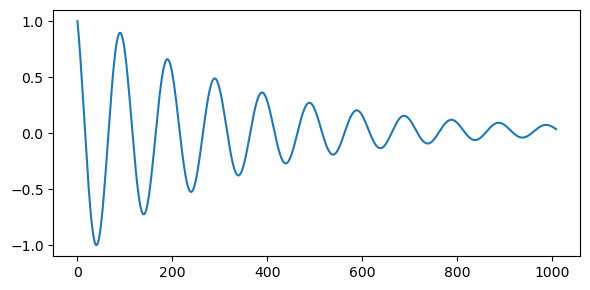

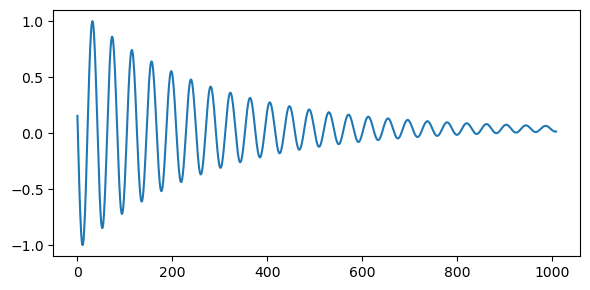

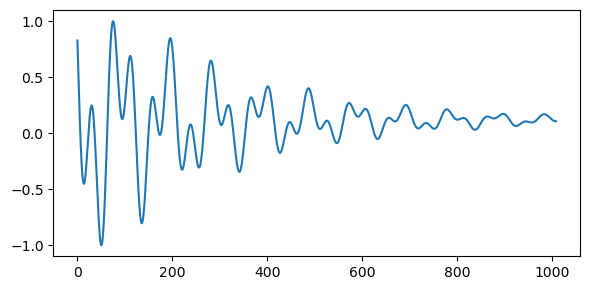

inf >> training files saved


In [4]:
# --! simulate with parameters -----------------------------------------------!

# --! define a list of simulation parameters
sim_params = [
    {
        'f_m'    : np.array([10.]),
        'q_m'    : np.array([10.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 17,
        'dt'     : 0.001,
    },
    {
        'f_m'    : np.array([24.]),
        'q_m'    : np.array([20.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 17,
        'dt'     : 0.001,
    },
    {
        'f_m'    : np.array([10., 24.]),
        'q_m'    : np.array([10., 20.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 17,
        'dt'     : 0.001,
    }
]

dets_sca = gen_detuning(sim_params)

# --! display resulting detuning
for det in dets_sca:
    disp_detuning(det)

# --! save timeseries
savedata_on   = True
savedata_dir  = 'train_sim_g'
savedata_sz   = 200
if savedata_on:
    utils.save_timeseries_train(dets_sca, savedata_dir, savedata_sz)
else:
    print('wrn >> global training file saving is switched off')

### Transient data for training

The transient data includes a transition from 10Hz to 24Hz and back to 10Hz.

inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2


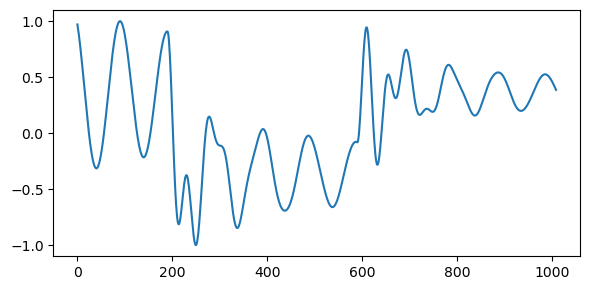

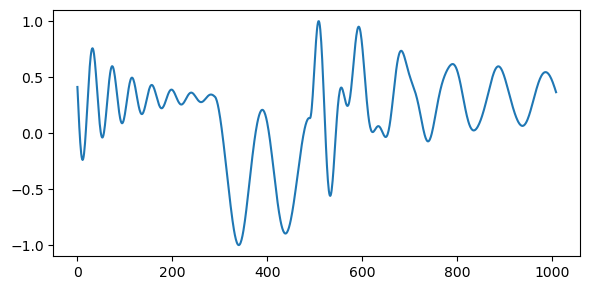

inf >> training files saved


In [5]:
# --! simulate with parameters -----------------------------------------------!

sim_params = [
    {
        'f_m'    : np.array([10., 24.]),
        'q_m'    : np.array([20., 5.]),
        't_m'    : np.array([[-1., -1.], [0.2, 0.6]]),
        't_rf_n' : 17,
        'dt'     : 0.001,
    },
    {
        'f_m'    : np.array([10., 24.]),
        'q_m'    : np.array([20., 7.]),
        't_m'    : np.array([[0.3, -1.], [-1., 0.5]]),
        't_rf_n' : 17,
        'dt'     : 0.001,
    }
]

dets_sca = gen_detuning(sim_params)

# --! display resulting detuning
for det in dets_sca:
    disp_detuning(det)

# --! save timeseries
savedata_on   = True
savedata_dir  = 'train_sim_l'
savedata_sz   = 200
if savedata_on:
    utils.save_timeseries_train(dets_sca, savedata_dir, savedata_sz)
else:
    print('wrn >> local training file saving is switched off')

### Transient data for model evaluation

inf >> number of mechanical modes specified: 2


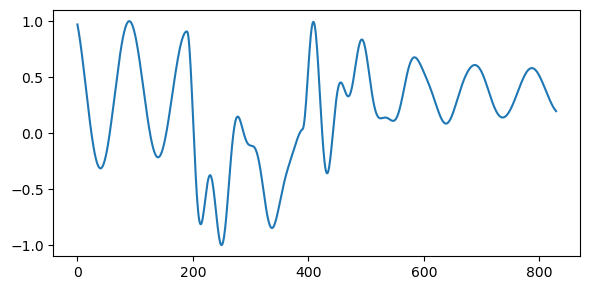

inf >> detuning length is 830 samples
inf >> evaluation file saved


In [6]:
sim_params = [
    {
        'f_m'    : np.array([10., 24.]),
        'q_m'    : np.array([20., 5.]),
        't_m'    : np.array([[-1., -1.], [0.2, 0.4]]),
        't_rf_n' : 14,
        'dt'     : 0.001,
    }
]

dets_sca = gen_detuning(sim_params)

# --! display resulting detuning
for det in dets_sca:
    disp_detuning(det)

print(f'inf >> detuning length is {len(dets_sca[0][:, 0])} samples')

# --! save timeseries
savedata_on   = True
savedata_dir  = 'eval_sim'
savedata_sz   = 200
if savedata_on:
    utils.save_timeseries_eval(dets_sca, savedata_dir, savedata_sz)
else:
    print('wrn >> evaluation file saving is switched off')